In [61]:
import numpy as np
import timeit
import time
from scipy.sparse.linalg import spilu, LinearOperator
from scipy.sparse import csc_matrix
import scipy.sparse as sp

In [62]:
n = 500


A = np.random.rand(n,n)

x = np.random.rand(n,1)

b = A@x
print(type(A))
A_symmetry = (A + A.T) / 2

#print(f"{A}\n{x=}\n{b=}")
sigma = 1.5
for i in range(n):
    row_sum = np.sum(np.abs(A_symmetry[i])) - np.abs(A_symmetry[i, i])
    A_symmetry[i, i] = row_sum + sigma

print(A_symmetry)

<class 'numpy.ndarray'>
[[2.52231540e+02 8.37771981e-01 5.59028988e-01 ... 3.81691142e-01
  1.47570901e-01 4.96220006e-01]
 [8.37771981e-01 2.45309439e+02 5.69773398e-01 ... 3.97110481e-01
  2.85306403e-01 4.71888989e-01]
 [5.59028988e-01 5.69773398e-01 2.55120111e+02 ... 8.37284612e-01
  5.45226881e-01 1.18323394e-01]
 ...
 [3.81691142e-01 3.97110481e-01 8.37284612e-01 ... 2.54778652e+02
  6.14804183e-01 4.19986859e-01]
 [1.47570901e-01 2.85306403e-01 5.45226881e-01 ... 6.14804183e-01
  2.48643404e+02 1.15654024e-01]
 [4.96220006e-01 4.71888989e-01 1.18323394e-01 ... 4.19986859e-01
  1.15654024e-01 2.58227262e+02]]


In [71]:
def LU(A):
    L = np.eye(A.shape[0], dtype=float)
    U = A
    
    for k in range(A.shape[0] - 1):
        for i in range(k + 1, A.shape[0]):
            factor = U[i, k] / U[k, k]
            L[i, k] = factor
            
            for j in range(k, A.shape[0]):
                U[i, j] -= factor * U[k, j]
            
    return L, U

def Solve_LU(A,b):
    L, U = LU(A)
    n = A.shape[0]
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i]
        for j in range(i):
            y[i] -= L[i, j] * y[j]
            
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = y[i]
        for j in range(i + 1, n):
            x[i] -= U[i, j] * x[j]
        x[i] /= U[i,i]            
    return x

def Kramer(A,b):
    main_det = np.linalg.det(A)
    b_shaped = b.reshape((A.shape[0],))
    x = []
    for i in range(A.shape[0]):
        A_buf = np.copy(A)
        A_buf[:,i] = b_shaped
        i_det = np.linalg.det(A_buf)
        x.append(i_det/main_det)
    return np.array(x)
        
def create_ilu_preconditioner(A):
    A_sparse = csc_matrix(A)

    try:
        ilu = spilu(A_sparse, drop_tol=1e-4, fill_factor=10)
        M = LinearOperator(A.shape, ilu.solve)

        return M
    except:
        print("BEBEBE")
        return LinearOperator(A.shape, lambda x: x)


def solve_gs(A, b, use_preconditioning=False, x0=None, etol=1e-8, max_iter=int(1e5)):
    n = A.shape[0]

    if x0 is None:
        x0 = np.zeros(n)

    x_current = x0.copy()

    if use_preconditioning:
        M = create_ilu_preconditioner(A)
    else:
        M = LinearOperator(A.shape, lambda x: x)

    for k in range(max_iter):
        x_old = x_current.copy()

        if use_preconditioning:
            r = b - A @ x_current
            z = M @ r
            x_current = x_current + z
        else:
            for i in range(n):
                sum1 = np.dot(A[i, :i], x_current[:i])
                sum2 = np.dot(A[i, i + 1 :], x_old[i + 1 :])
                x_current[i] = (b[i] - sum1 - sum2) / A[i, i]

        if np.linalg.norm(x_current - x_old) < etol:
            print(k)
            break
    return x_current, k + 1

def timed_GS():
    solve_gs(A_symmetry,b,1e-8,np.zeros_like(b))

def timed_Kramer():
    Kramer(A_symmetry,b)

def timed_LU():
    Solve_LU(A_symmetry,b)


In [72]:
r1 = (Solve_LU(A_symmetry,b))

r2 = (Kramer(A_symmetry,b))
s=time.time()
r3 = (solve_gs(A_symmetry,b))
e = time.time()
time_taken = timeit.timeit(timed_Kramer,number=1)
print(f"Kramer = {time_taken}")

time_taken = timeit.timeit(timed_LU,number=1)
print(f"LU = {time_taken}")
print(f"GS = {e-s}")


C:\Users\Amik29\AppData\Local\Temp\ipykernel_2404\2201239440.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[i] = b[i]
C:\Users\Amik29\AppData\Local\Temp\ipykernel_2404\2201239440.py:40: RuntimeWarning: invalid value encountered in scalar divide
  x.append(i_det/main_det)
C:\Users\Amik29\AppData\Local\Temp\ipykernel_2404\2201239440.py:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_current[i] = (b[i] - sum1 - sum2) / A[i, i]


11
Kramer = 7.567218500073068
LU = 9.12207549996674
GS = 0.027999401092529297


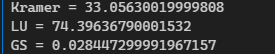


In [76]:
_, k_prec = solve_gs(A, b, use_preconditioning=True)


2
